In [1]:
base_dir = "/home/shaeo/cadd_training/20251012_docking"

## データの前処理

### リガンド

In [2]:
import os
from rdkit.Chem import PandasTools

In [3]:
data_src_path = "/home/shaeo/cadd_training/20250816_ChEMBLAPI/dataset/dataset_EGFR.sdf"
data_dist_sdf_path = base_dir + "/data/EGFR.sdf"
data_dist_smi_path = base_dir + "/data/EGFR.smi"
gypsum_output_dir = base_dir + "/data/3dmol"

In [11]:
# データを抽出
df = PandasTools.LoadSDF(data_src_path)
df_select = df.sample(n=20, random_state=42)

In [12]:
# .smiとして保存
df_smi = df_select.loc[:, ["smiles", "ID"]]
df_smi.to_csv(data_dist_smi_path, index=False, header=False, sep="\t")

In [13]:
# .sdfとして保存
for name, mol in zip(df["ID"], df["ROMol"]):
    mol.SetProp("_Name", name)
df_select.drop(columns="ID", inplace=True)
PandasTools.WriteSDF(df_select, data_dist_sdf_path, properties=list(df_select.columns))

In [17]:
# リガンドの3次元化
%cd /home/shaeo/opt/gypsum_dl
!python run_gypsum_dl.py \
    --source $data_dist_smi_path \ 
    --output_folder $gypsum_output_dir \
    --job_manager multiprocessing \
    --num_processors 8 \
    --max_variants_per_compound 1 \
    --separate_output_files \
    --min_ph 7.4 \
    --max_ph 7.4 \
    --skip_making_tautomers \
    --skip_enumerate_chiral_mol \
    --skip_enumerate_double_bonds
%cd $base_dir

/home/shaeo/opt/gypsum_dl

If you use Gypsum-DL in your research, please cite:

Ropp, Patrick J., Jacob O. Spiegel, Jennifer L. Walker, Harrison Green,
Guillermo A. Morales, Katherine A. Milliken, John J. Ringe, and Jacob D. Durrant.
(2019) Gypsum-DL: An Open-source Program for Preparing Small-molecule Libraries for 
Structure-based Virtual Screening. Journal of Cheminformatics 11:1. 
doi:10.1186/s13321-019-0358-3.

    Gypsum-DL-generated variants, we have identified a number of substructures
    that, though technically possible, strike us as improbable or otherwise
    poorly suited for virtual screening. We strongly recommend removing these by
    running Gypsum-DL with the --use_durrant_lab_filters option.

Loading molecules from EGFR.smi...
Desalting all molecules (i.e., keeping only largest fragment).
    Contents of MolContainers
        MolContainer #0 (CHEMBL15346)
            Mol #0: CS(=O)(=O)CCNCCCCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1
        MolContainer #1 (CHEMBL48905

In [24]:
# ファイル名の処理
list_sdf_pre = [f for f in os.listdir(gypsum_output_dir) if not "gypsum" in f]
for sdf in list_sdf_pre:
    os.rename(gypsum_output_dir + f"/{sdf}", gypsum_output_dir + f"/{sdf.split('__')[0]}.sdf")

### レセプター

In [4]:
import requests
from pdbfixer import PDBFixer
from openmm.app import PDBFile
from Bio import PDB

In [5]:
pdb_id = "2ITO"
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
out_file = base_dir + f"/data/{pdb_id}.pdb"
ligand_pdb_file = base_dir + f"/data/ligand_{pdb_id}.pdb"
ligand_sdf_file = base_dir + f"/data/ligand_{pdb_id}.sdf"
protein_file = base_dir + f"/data/receptor_{pdb_id}.pdb"

In [19]:
# ファイルのダウンロード
response = requests.get(url)
if response.status_code == 200:
    with open(out_file, "wb") as f:
        f.write(response.content)
else:
    print(f"Failed to fetch {pdb_id}")

In [24]:
# リガンドを抽出（ボックス用）
ligand_resname = "IRE"

parser = PDB.PDBParser(QUIET=True)
structure = parser.get_structure("complex", out_file)
io = PDB.PDBIO()

# リガンドを抽出
class LigandSelect(PDB.Select):
    def accept_residue(self, residue):
        return residue.get_resname().strip() == ligand_resname
io.set_structure(structure)
io.save(ligand_pdb_file, LigandSelect())

# リガンドのファイル形式を変換
!obabel $ligand_pdb_file -O $ligand_sdf_file -p 7.4

1 molecule converted


In [17]:
# クレンジング
fixer = PDBFixer(filename=out_file)
fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues()
fixer.removeHeterogens(keepWater=False)
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(pH=7.4)
with open(protein_file, "w") as f:
    PDBFile.writeFile(fixer.topology, fixer.positions, f, keepIds=True)

## ドッキングシミュレーション

In [6]:
from rdkit import Chem
import pandas as pd

In [7]:
gnina_dir = base_dir + "/gnina"
os.makedirs(gnina_dir, exist_ok=True)
docked_dir = base_dir + "/docked"
os.makedirs(docked_dir, exist_ok=True)
docked_top_dir = docked_dir + "/top"
os.makedirs(docked_top_dir, exist_ok=True)

In [12]:
# コンテナを立ち上げる
!docker run -d \
    --name gnina \
    -v $base_dir:/root/base \
    --gpus all \
    gnina/gnina \
    tail -f /dev/null

4f355231c84703525c2621c941fbea68d5255585f734ab99adcdf65da3b30603


In [29]:
# ドッキングシミュレーション
list_sdf = [f for f in os.listdir(gypsum_output_dir) if not "gypsum" in f]
for sdf in list_sdf:
    !docker exec -it gnina \
        gnina \
        -r /root/base/data/receptor_2ITO.pdb \
        -l /root/base/data/3dmol/{sdf} \
        --autobox_ligand /root/base/data/ligand_2ITO.sdf \
        --exhaustiveness 32 \
        -o /root/base/gnina/{sdf}.gz
    !docker exec -it gnina \
        gunzip /root/base/gnina/{sdf}.gz

              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina v1.3.1 master:5bd63bd   Built May 23 2025.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Commandline: gnina -r /root/base/data/receptor_2ITO.pdb -l /root/base/data/3dmol/CHEMBL5176295.sdf --autobox_ligand /root/base/data/ligand_2ITO.sdf --exhaustiveness 32 -o /root/base/gnina/CHEMBL5176295.sdf.gz
Using random seed: 710392616

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************
CHEMBL5176295 | pose 0 | initial pose not within box

mode |  affinity  |  intramol  |    CNN     |   CNN
     | (kcal/mol) | (kcal/mol) | pose score | affinity
-----+------------+------------+------------+----------
    1       -6.68       -0.07   

In [ ]:
# コンテナの削除
!docker container stop gnina
!docker container rm gnina

In [31]:
# プロトン化
for sdf in list_sdf:
    !obabel $gnina_dir/{sdf} -O $docked_dir/{sdf} -p 7.4

9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted
9 molecules converted


In [45]:
# スコア最上位の分割
df_gnina = pd.DataFrame()
for sdf in list_sdf:
    _df = PandasTools.LoadSDF(docked_dir + f"/{sdf}", removeHs=False)
    _df = _df.loc[0, :]
    df_gnina = pd.concat([df_gnina, _df], axis=1)
    _df["ROMol"].SetProp("_Name", _df["ID"])
    _df["ROMol"].SetProp("SMILES", _df["SMILES"])
    _df["ROMol"].SetProp("Energy", _df["Energy"])
    _df["ROMol"].SetProp("minimizedAffinity", _df["minimizedAffinity"])
    _df["ROMol"].SetProp("CNNscore", _df["CNNscore"])
    _df["ROMol"].SetProp("CNNaffinity", _df["CNNaffinity"])
    _df["ROMol"].SetProp("CNN_VS", _df["CNN_VS"])
    _df["ROMol"].SetProp("CNNaffinity_variance", _df["CNNaffinity_variance"])
    writer = Chem.SDWriter(docked_top_dir + f"/{sdf}")
    writer.write(_df["ROMol"])
    writer.close()
df_gnina.T.to_csv(docked_top_dir + "/gnina_result.scv", index=False)

## Uni-GBSA

In [9]:
# Uni-GBSA
for sdf in list_sdf:
    gbsa_dir = base_dir + f"/uni_gbsa/{sdf.split('.')[0]}"
    os.makedirs(gbsa_dir, exist_ok=True)
    %cd $gbsa_dir
    !unigbsa-pipeline \
        -i ../../data/receptor_2ITO.pdb \
        -l ../../docked/top/{sdf} \
        -o BindingEnergy.csv
%cd !base_dir

/home/shaeo/cadd_training/20251012_docking/uni_gbsa/CHEMBL5176295
10/12/2025 20:54:30 PM - INFO - Build protein topology.
10/12/2025 20:54:31 PM - INFO - Build ligand topology: CHEMBL5176295
10/12/2025 20:54:34 PM - INFO - Running energy minimization: CHEMBL5176295
10/12/2025 20:54:37 PM - INFO - Run the MMPB(GB)SA.
10/12/2025 20:54:53 PM - INFO - Clean the results.
Results: Energy.csv Dec.csv
Frames    mode    delta_G(kcal/mole)
     1      gb              -39.0606  
/home/shaeo/cadd_training/20251012_docking/uni_gbsa/CHEMBL5188568
10/12/2025 20:54:54 PM - INFO - Build protein topology.
10/12/2025 20:54:56 PM - INFO - Build ligand topology: CHEMBL5188568
10/12/2025 20:54:58 PM - INFO - Running energy minimization: CHEMBL5188568
10/12/2025 20:55:01 PM - INFO - Run the MMPB(GB)SA.
10/12/2025 20:55:17 PM - INFO - Clean the results.
Results: Energy.csv Dec.csv
Frames    mode    delta_G(kcal/mole)
     1      gb              -58.9328  
/home/shaeo/cadd_training/20251012_docking/uni_gbsa/CH

In [14]:
# データの集約
df_gbsa = pd.DataFrame()
for sdf in list_sdf:
    gbsa_path = base_dir + f"/uni_gbsa/{sdf.split('.')[0]}/BindingEnergy.csv"
    _df = pd.read_csv(gbsa_path)
    df_gbsa = pd.concat([df_gbsa, _df], axis=0)
df_gbsa.to_csv(base_dir + "/uni_gbsa/gbsa_result.csv", index=False)
df_gbsa

,ligandName,Frames,mode,complex,receptor,ligand,Internal,Van der Waals,Electrostatic,Polar Solvation,Non-Polar Solvation,Gas,Solvation,TOTAL,status
0,CHEMBL5176295,1,gb,502.987788,536.453338,5.594992,-2.575717e-14,-38.2312,-2.4385,7.5205,-5.911343,-40.6698,1.609157,-39.060643,S
0,CHEMBL5188568,1,gb,562.855588,584.017011,37.771433,-1.000000e-04,-57.0099,-73.3145,78.8753,-7.483656,-130.3244,71.391644,-58.932756,S
0,CHEMBL464721,1,gb,574.295622,580.805689,39.703436,6.350476e-14,-45.3059,8.9560,-1.9487,-7.914903,-36.3499,-9.863603,-46.213503,S
0,CHEMBL1958028,1,gb,533.808766,557.275643,20.327724,7.682743e-14,-40.9694,-33.9541,36.7056,-5.576700,-74.9235,31.128900,-43.794600,S
0,CHEMBL4439338,1,gb,472.034539,488.698148,39.012940,1.000000e-04,-56.3203,-85.4103,94.2507,-8.196749,-141.7306,86.053951,-55.676649,S
0,CHEMBL4278886,1,gb,393.072743,455.032211,-8.745934,-9.015011e-14,-52.0760,-3.5187,9.6180,-7.236834,-55.5948,2.381166,-53.213634,S
0,CHEMBL1242032,1,gb,586.697939,644.508407,-18.838353,-1.767475e-13,-37.1515,-5.8351,8.6701,-4.655615,-42.9865,4.014485,-38.972015,S
0,CHEMBL3932338,1,gb,923.264040,941.808928,25.949936,1.000000e-04,-44.8802,-5.8498,12.1022,-5.867124,-50.7300,6.235076,-44.494924,S
0,CHEMBL115187,1,gb,800.670642,839.617771,16.626491,1.000000e-04,-54.0732,-34.6135,40.7330,-7.620021,-88.6867,33.112979,-55.573721,S
0,CHEMBL1830273,1,gb,557.496576,539.696829,54.386500,-1.000000e-04,-31.0122,-45.5333,45.3398,-5.380953,-76.5455,39.958847,-36.586653,S


## プロット

In [23]:
import matplotlib.pyplot as plt

In [16]:
# データの読み込み
df_base = PandasTools.LoadSDF(data_dist_sdf_path)
df_gnina = pd.read_csv(docked_top_dir + "/gnina_result.scv")
df_gbsa = pd.read_csv(base_dir + "/uni_gbsa/gbsa_result.csv")

In [20]:
# ID順に並べ替え
df_base.sort_values(by="ID", ascending=True, inplace=True)
df_gnina.sort_values(by="ID", ascending=True, inplace=True)
df_gbsa.sort_values(by="ligandName", ascending=True, inplace=True)

In [22]:
# マージ
df_base = pd.concat(
    [
        df_base, 
        df_gnina.loc[:, ["minimizedAffinity", "CNNaffinity"]],
        df_gbsa.loc[:, "TOTAL"]            
                     ],
    axis=1
)
df_base

,molecule_chembl_id,IC50,units,smiles,pIC50,ID,ROMol,minimizedAffinity,CNNaffinity,TOTAL
0,CHEMBL15346,74.0,nM,CS(=O)(=O)CCNCCCCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4...,7.130768,CHEMBL15346,<rdkit.Chem.rdchem.Mol object at 0x7463bfec40b0>,-6.67759,6.133642,-39.060643
1,CHEMBL489058,10.0,nM,CCN1CCN(CC/C=C/c2ccc3c(Nc4ccc(Sc5nccn5C)c(Cl)c...,8.0,CHEMBL489058,<rdkit.Chem.rdchem.Mol object at 0x7463bfec4270>,-9.53695,8.047400,-58.932756
2,CHEMBL3967962,405.0,nM,O=C(/C=C/CN1CCCC1)Nc1cc2c(Nc3ccc(Cc4ccccn4)cc3...,6.392545,CHEMBL3967962,<rdkit.Chem.rdchem.Mol object at 0x7463bfec4430>,-7.70871,5.979725,-46.213503
3,CHEMBL3612592,140.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(F)c4)c...,6.853872,CHEMBL3612592,<rdkit.Chem.rdchem.Mol object at 0x7463bfec44a0>,-8.96863,6.453931,-43.794600
4,CHEMBL115187,130.0,nM,CCCN(CC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c...,6.886057,CHEMBL115187,<rdkit.Chem.rdchem.Mol object at 0x7463bfec4580>,-8.55559,7.559897,-55.676649
5,CHEMBL3353408,200.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3c[nH]c4ccccc34)n2...,6.69897,CHEMBL3353408,<rdkit.Chem.rdchem.Mol object at 0x7463bfec4660>,-9.48756,7.425375,-53.213634
6,CHEMBL3612591,2300.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5ccccn5...,5.638272,CHEMBL3612591,<rdkit.Chem.rdchem.Mol object at 0x7463bfec4740>,-8.22945,6.469247,-38.972015
7,CHEMBL5188568,9.2,nM,C=CC(=O)N1CCC(N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(...,8.036212,CHEMBL5188568,<rdkit.Chem.rdchem.Mol object at 0x7463bfec47b0>,-8.16640,7.538298,-44.494924
8,CHEMBL3357645,16.4,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CC...,7.785156,CHEMBL3357645,<rdkit.Chem.rdchem.Mol object at 0x7463bfec4890>,-7.19868,8.006110,-55.573721
9,CHEMBL1242032,100000.0,nM,CC(C)n1nc(-c2ccc(S(N)(=O)=O)cc2)c2c(N)ncnc21,4.0,CHEMBL1242032,<rdkit.Chem.rdchem.Mol object at 0x7463bfec4900>,-7.62547,5.982737,-36.586653


In [25]:
# float化
df_base["pIC50"] = df_base["pIC50"].astype(float)
df_base["minimizedAffinity"] = df_base["minimizedAffinity"].astype(float)
df_base["CNNaffinity"] = df_base["CNNaffinity"].astype(float)
df_base["TOTAL"] = df_base["TOTAL"].astype(float)

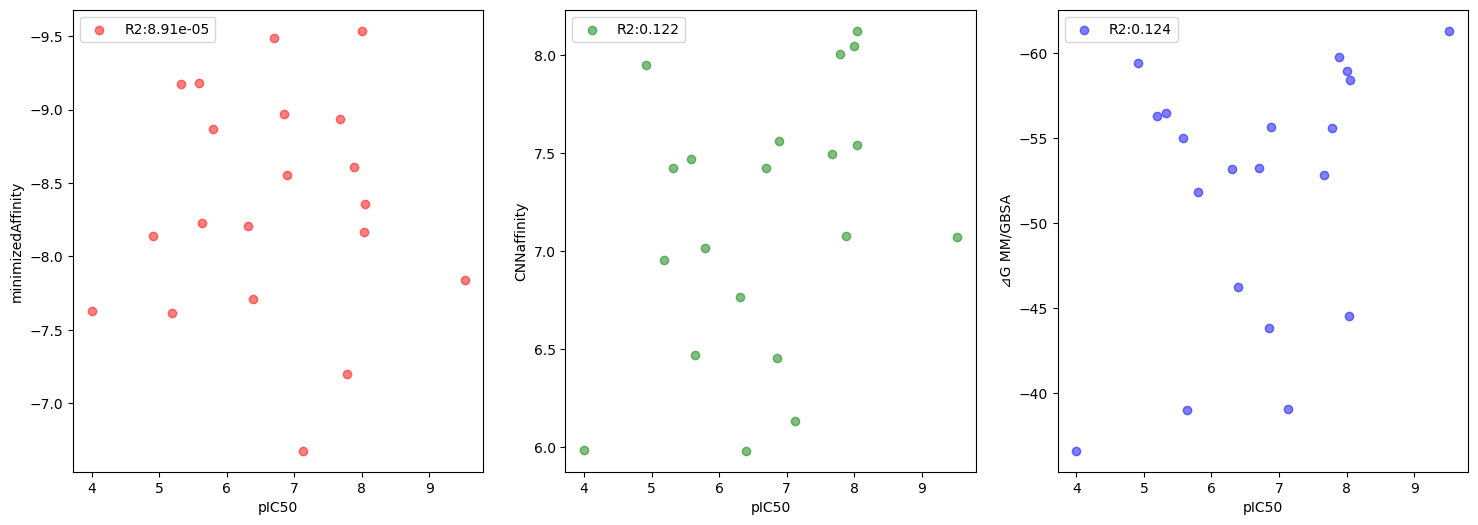

In [29]:
# プロット
r2_smina = df_base["pIC50"].corr(df_base["minimizedAffinity"])**2
r2_gnina = df_base["pIC50"].corr(df_base["CNNaffinity"])**2
r2_gbsa = df_base["pIC50"].corr(df_base["TOTAL"])**2

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(df_base["pIC50"], df_base["minimizedAffinity"], c="r", alpha=0.5, label=f"R2:{r2_smina:.3}")
ax[0].invert_yaxis() 
ax[0].set_xlabel("pIC50")
ax[0].set_ylabel("minimizedAffinity")
ax[0].legend()
ax[1].scatter(df_base["pIC50"], df_base["CNNaffinity"], c="g", alpha=0.5, label=f"R2:{r2_gnina:.3}")
ax[1].set_xlabel("pIC50")
ax[1].set_ylabel("CNNaffinity")
ax[1].legend()
ax[2].scatter(df_base["pIC50"], df_base["TOTAL"], c="b", alpha=0.5, label=f"R2:{r2_gbsa:.3}")
ax[2].invert_yaxis() 
ax[2].set_xlabel("pIC50")
ax[2].set_ylabel("⊿G MM/GBSA")
ax[2].legend()
plt.show()